# Time-Series Momentum on a Diversified ETF Basket

A trend-following strategy that takes long or short positions in eight ETFs across
equities, fixed income, commodities, and real estate, based on the sign of each
asset's own past returns.

**Headline:** Over 2007–2025, the strategy produced a Sharpe of 0.59 with a max drawdown of -19.4%, a beta to SPY of 0.008, and an alpha of 5.58% per year (t ≈ 2.6, before accounting for the variants tried; see Limitations). Its main value is as a diversifier: a return stream with near-zero average correlation to equities (although the rolling correlation swings between roughly -0.9 and +0.8) and a much shallower worst-case drawdown than SPY's -55.2%.

## Method

The strategy follows the Moskowitz, Ooi, and Pedersen (2012) time-series momentum
framework.

1. **Signal.** At each month-end, for each asset, compute the sign of its past
   return over 6 months and over 12 months. Average the two signs. The result
   ranges from -1 (both horizons down) to +1 (both horizons up).
2. **Sizing.** Target 20% annualized volatility per asset by scaling each position
   inversely to its trailing 60-day realized volatility, capped at 2× leverage.
3. **Timing.** Decide at the month-end close, hold the position fixed until the
   next month-end. Returns are earned from the day after the decision.
4. **Costs.** 5 basis points per dollar traded.
5. **Portfolio.** Equal average across the eight assets, since each is already
   vol-targeted and therefore contributes roughly equal risk.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tsmom_monthly import (
    load_prices, backtest, portfolio_turnover,
    HORIZONS, SKIP_MONTHS, TARGET_VOL, VOL_WINDOW, MAX_LEVERAGE, COST_BPS, TICKERS,
)
from stats import (
    perf, print_perf, bootstrap_sharpe_ci, regress_on_benchmark, print_regression,
    conditional_on_drawdown, print_conditional, subperiod_stats, print_subperiod,
    calendar_year_returns, print_calendar, top_drawdowns, print_top_drawdowns,
    portfolio_combination, print_portfolio_combination,
    cost_sensitivity, print_cost_sensitivity,
    asset_contribution, print_asset_contribution,
    random_walk_test,
    plot_equity_curve, plot_drawdowns, plot_rolling_sharpe, plot_rolling_correlation,
)

pd.set_option("display.width", 140)

In [22]:
daily = load_prices()

port, position, costs = backtest(
    daily, HORIZONS, SKIP_MONTHS, TARGET_VOL, VOL_WINDOW, MAX_LEVERAGE, COST_BPS
)

spy = daily["SPY"].pct_change(fill_method=None).reindex(port.index)
gross = port + costs.mean(axis=1)      # portfolio gross return (before costs)
turnover = portfolio_turnover(position)

print(f"Period:    {port.index[0].date()} to {port.index[-1].date()}")
print(f"Universe:  {len(TICKERS)} ETFs")
print(f"Trading days: {len(port)}")

Period:    2007-02-28 to 2025-12-31
Universe:  8 ETFs
Trading days: 4742


## Headline results

The strategy is compared against SPY buy-and-hold over the same period. SPY is
not excess-of-cash, matching the strategy's Sharpe convention.

In [23]:
stats_strat = perf(port)
stats_spy = perf(spy)

print_perf(stats_strat, "TSMOM (net)")
print_perf(stats_spy, "SPY buy-and-hold (same period)")

=== TSMOM (net) ===
  CAGR          :   5.34%
  Ann Vol       :   9.65%
  Sharpe        :    0.59
  Max DD        : -19.42%
  Calmar        :    0.28
  Total Return  : 166.38%
  N days        :    4742

=== SPY buy-and-hold (same period) ===
  CAGR          :  10.85%
  Ann Vol       :  19.81%
  Sharpe        :    0.62
  Max DD        : -55.19%
  Calmar        :    0.20
  Total Return  : 595.27%
  N days        :    4742



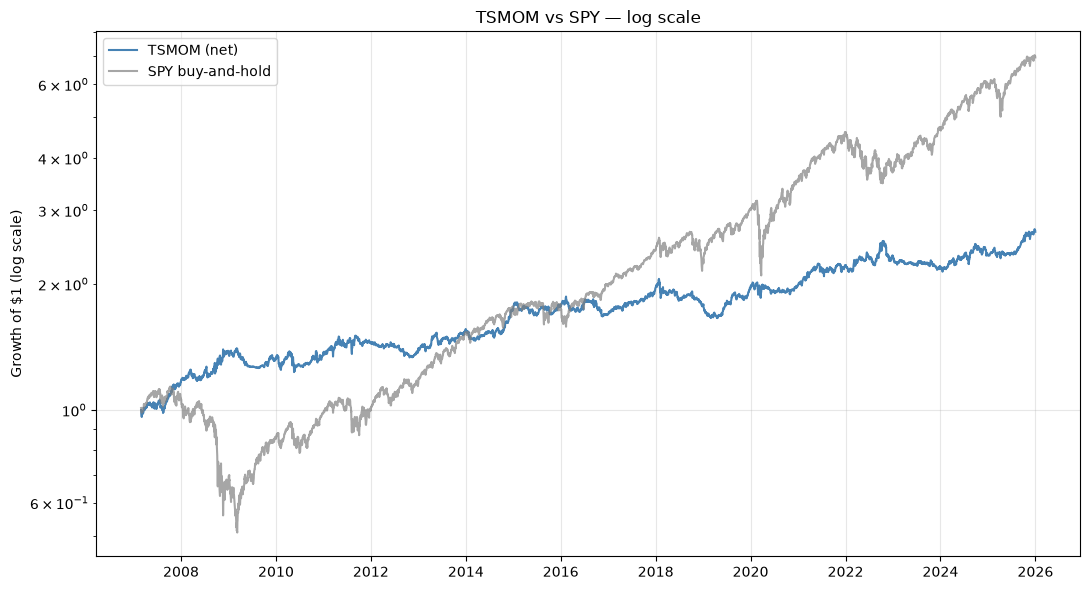

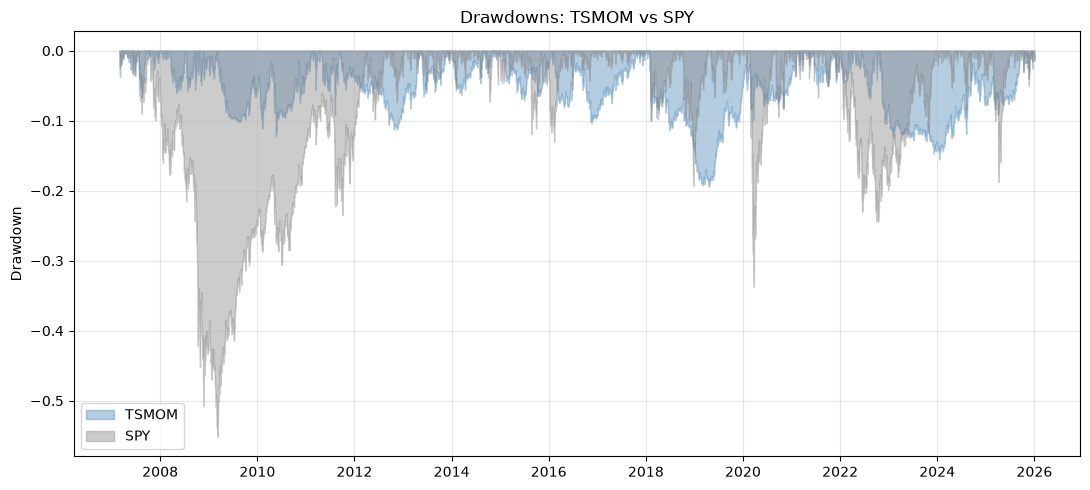

In [24]:
plot_equity_curve(port, spy, title="TSMOM vs SPY — log scale")
plot_drawdowns(port, spy)

The strategy delivers a Sharpe comparable to SPY's with about half the volatility and about a third of the drawdown. The log-scale equity curve shows it led SPY until roughly 2014–2016, including through 2008, when SPY lost 36.8% for the year (55% peak-to-trough) while the strategy gained 17.6%. SPY then pulled away during 2016–2019 and again in 2023–2025. The drawdown chart makes the asymmetry clear: the strategy's worst drawdown is -19.4%, less than half of SPY's -55.2%.

## Is the result real? Regression and bootstrap

Two tests. First, regress the strategy's daily returns on SPY's to separate alpha
from market beta. Second, bootstrap the Sharpe to see how much uncertainty
surrounds it.

In [25]:
reg = regress_on_benchmark(port, spy)
print_regression(reg, "Regression: TSMOM on SPY (Newey-West, 5 lags)")

=== Regression: TSMOM on SPY (Newey-West, 5 lags) ===
  Alpha (ann)   :   5.58%
  Beta          :   0.008
  t(alpha)      :   2.578
  t(beta)       :   0.301
  R^2           :   0.000
  Corr          :   0.016
  N days        :    4742



In [26]:
lo, hi = bootstrap_sharpe_ci(port, n_boot=2000, block=21, seed=0)
print(f"Sharpe: {perf(port)['Sharpe']:.2f}  95% CI: [{lo:.2f}, {hi:.2f}]")

Sharpe: 0.59  95% CI: [0.18, 1.00]


The regression shows an **alpha of roughly 5.6% per year** (t ≈ 2.6) with a **beta of 0.008** that is statistically indistinguishable from zero (t = 0.3). SPY explains less than 0.1% of the strategy's variance. Because beta is essentially zero, the alpha is close to the strategy's average return, so this t-statistic is the same evidence as the Sharpe ratio rather than an independent confirmation. It is also a full-sample average: the rolling correlation below shows that the relationship to SPY is far from constant.

The bootstrap 95% CI on Sharpe is [0.18, 1.00]. That is wide—19 years of daily data is not enough to pin down Sharpe precisely—but the lower bound stays positive, which supports a positive risk-adjusted return. It does not rule out a true Sharpe near 0.2.

## Regime dependence

Trend following is known to have had a difficult decade in the 2010s. Splitting the sample at 2020 checks whether the result depends on one era.

In [27]:
sp = subperiod_stats(port, spy, splits=("2020-01-01",))
print_subperiod(sp)

=== Sub-period results ===
  2007-2019  Strategy:  CAGR  5.34%  Vol  9.73%  Sharpe  0.58  MaxDD -19.4%
             Benchmark: CAGR  8.96%  Vol 19.36%  Sharpe  0.54  MaxDD -55.2%
  2020-2025  Strategy:  CAGR  5.34%  Vol  9.47%  Sharpe  0.60  MaxDD -15.5%
             Benchmark: CAGR 15.03%  Vol 20.74%  Sharpe  0.78  MaxDD -33.7%



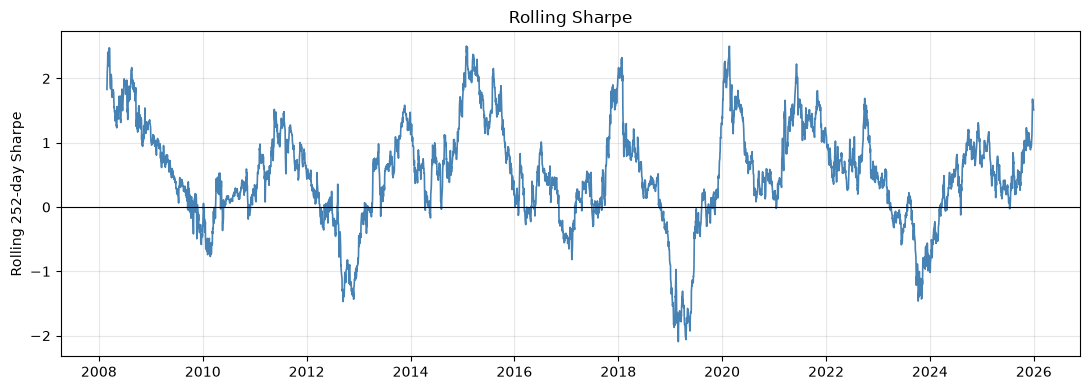

In [28]:
plot_rolling_sharpe(port, window=252)

The split shows stability rather than regime dependence: Sharpe is 0.58 in 2007–2019 and 0.60 in 2020–2025, with the same CAGR (5.34%) in both. The rolling one-year Sharpe, however, ranges from about -2 to +2.5, so any single year says little. The weakest calendar years were 2018 (-9.2%), 2023 (-5.2%), 2012 (-4.7%), 2016 (-4.6%) and 2009 (-3.7%); the strongest were 2008 (+17.6%), 2017 (+15.4%), 2025 (+13.9%) and 2013 (+12.8%). There is no clean link to equity volatility: 2017, one of the calmest years for equities in the sample, was one of the best years for the strategy. Several weak years (2009, 2016, 2018, 2023) followed sharp reversals in prior trends, which would explain whipsaw losses, but that is a hypothesis this analysis does not test.

## Behaviour during equity drawdowns

The strategy's value is most visible when equities are falling. The table below
compares strategy and SPY performance inside and outside SPY's drawdowns deeper
than 10%. The rolling correlation plot shows how the relationship changes over
time.

In [29]:
cond = conditional_on_drawdown(port, spy, threshold=-0.10)
print_conditional(cond)

=== Conditional on benchmark drawdown (>10%) ===
  Regime                  Days    Share  StratRet  BenchRet
  In drawdown             1304    27.5%     1.31%   -13.29%
  Outside drawdown        3438    72.5%     6.92%    21.68%



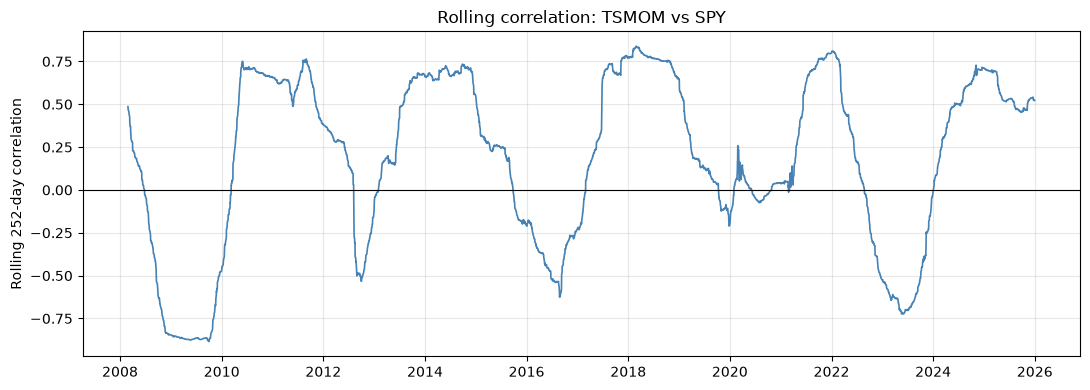

In [30]:
plot_rolling_correlation(port, spy, window=252)

Inside SPY drawdowns (27.5% of days), SPY lost 13.3% annualized on average while the strategy gained 1.3%. Outside drawdowns SPY compounded at 21.7% and the strategy at 6.9%. The "in drawdown" regime lasts until SPY gets back within 10% of its prior peak, so it includes recovery rallies (for example much of 2009–2012), not only falling markets, and the strategy's 2009 loss (-3.7%) fell in that regime. The trade-off in numbers: give up upside in bull markets, avoid most of the damage in crashes.

The rolling correlation chart shows that the near-zero full-sample correlation (0.02) is an average of very different regimes. The 252-day correlation reaches about +0.8 (2018 and 2021–22, consistent with the strategy being long equities in sustained uptrends) and about -0.9 (2008–09), with other negative stretches around 2012, 2016 and 2023. So the strategy is not uncorrelated with equities at any given time. It is what makes it a diversifier in a crash like 2008, but a negative correlation window also includes rebounds, which hurt (2009).

## Robustness

Three checks: sensitivity to the cost assumption, sensitivity to parameters, and
a sanity test on synthetic data to rule out look-ahead.

In [31]:
cs = cost_sensitivity(gross, turnover, bps_list=(0, 1, 3, 5, 10, 20))
print_cost_sensitivity(cs)

=== Cost sensitivity ===
  Cost (bps)        CAGR    Sharpe     MaxDD
  0                5.62%      0.62    -19.1%
  1                5.56%      0.61    -19.1%
  3                5.45%      0.60    -19.3%
  5                5.34%      0.59    -19.4%
  10               5.07%      0.56    -19.8%
  20               4.52%      0.51    -20.5%



In [32]:
grid_horizons = [(3, 6, 12), (6, 12), (12,), (3, 12), (1, 3, 12)]
grid_vol_windows = [20, 40, 60, 120]

print(f"  {'horizons':<16}{'vol win':>8}{'Sharpe':>9}{'CAGR':>9}{'MaxDD':>9}")
for hz in grid_horizons:
    for vw in grid_vol_windows:
        p, _, _ = backtest(daily, list(hz), SKIP_MONTHS, TARGET_VOL, vw,
                           MAX_LEVERAGE, COST_BPS)
        s = perf(p)
        print(f"  {str(hz):<16}{vw:>8}{s['Sharpe']:>9.2f}"
              f"{s['CAGR']:>9.2%}{s['Max DD']:>9.1%}")

  horizons         vol win   Sharpe     CAGR    MaxDD
  (3, 6, 12)            20     0.58    5.18%   -15.6%
  (3, 6, 12)            40     0.61    5.43%   -15.9%
  (3, 6, 12)            60     0.60    5.25%   -15.6%
  (3, 6, 12)           120     0.57    4.98%   -17.4%
  (6, 12)               20     0.56    5.16%   -19.9%
  (6, 12)               40     0.60    5.52%   -19.8%
  (6, 12)               60     0.59    5.34%   -19.4%
  (6, 12)              120     0.55    4.96%   -21.2%
  (12,)                 20     0.52    5.19%   -24.5%
  (12,)                 40     0.54    5.39%   -24.2%
  (12,)                 60     0.52    5.10%   -24.1%
  (12,)                120     0.47    4.56%   -26.4%
  (3, 12)               20     0.58    5.22%   -15.7%
  (3, 12)               40     0.59    5.34%   -16.2%
  (3, 12)               60     0.57    5.09%   -16.0%
  (3, 12)              120     0.54    4.81%   -18.0%
  (1, 3, 12)            20     0.46    3.79%   -15.6%
  (1, 3, 12)            40  

In [33]:
rw = random_walk_test(n_seeds=20, cost_bps=0)
print(f"Mean Sharpe over {rw['N seeds']} zero-drift seeds: {rw['Mean Sharpe']:+.4f}")
print(f"Standard error: {rw['Std Err']:.4f}")
print(f"Range: [{rw['Min']:+.3f}, {rw['Max']:+.3f}]")

Mean Sharpe over 20 zero-drift seeds: +0.0092
Standard error: 0.0424
Range: [-0.298, +0.455]


The cost-sensitivity table shows the Sharpe degrading gracefully as costs rise: from 0.62 at 0 bps to 0.59 at the assumed 5 bps and 0.51 at 20 bps. In the parameter grid, every variant without a 1-month horizon lands between 0.47 and 0.61, within the noise band of the 0.59 baseline (the standard error of a 19-year Sharpe is roughly 0.25). Variants that add a 1-month horizon are consistently lower (0.42–0.48), probably because that horizon is noisy. The baseline (6, 12 at 60 days) is not the best cell (3, 6, 12 at 40 days gets 0.61), so the result does not look cherry-picked. The random walk test is the cleanest check for look-ahead: on data with no trend, the pipeline produces no Sharpe on average (mean +0.009, standard error 0.042). If there were look-ahead bias, this number would be clearly positive.

## Where the returns come from

Vol targeting gives low-volatility assets (bonds) larger positions than
high-volatility assets (equities), so it is worth checking whether the strategy's
return is really diversified across asset classes or concentrated in rates.

In [34]:
ac = asset_contribution(position, daily.pct_change(fill_method=None))
print_asset_contribution(ac)

=== Per-asset gross P&L contribution ===
  Asset            P&L     Share
  SPY           2.3073     25.8%
  GLD           2.0310     22.7%
  DBC           1.2715     14.2%
  EEM           0.8723      9.8%
  IEF           0.8327      9.3%
  EFA           0.6727      7.5%
  VNQ           0.5069      5.7%
  TLT           0.4376      4.9%



The returns are not concentrated in rates. Bonds (IEF and TLT combined) contribute only about 14% of gross P&L, while equities (SPY, EFA, EEM) contribute roughly 43% and commodities (GLD, DBC) another 37%. The strategy is reasonably diversified across asset classes, which is the design intent of the broad ETF universe, although SPY (25.8%) and GLD (22.7%) alone account for nearly half of gross P&L, and gold had a strong run over this sample. The concern that inverse-vol sizing would give bonds an outsized influence does not materialise in the realized P&L contribution.

## The practical case: combining with equities

A strategy that cannot be combined with an equity portfolio is of limited value.
The table below shows the risk-adjusted return of an 80/20 or 70/30 SPY/TSMOM
portfolio versus 100% SPY.

In [35]:
pc = portfolio_combination(port, spy, weights=(0.0, 0.1, 0.2, 0.3, 0.4))
print_portfolio_combination(pc)

=== Portfolio combination: benchmark + strategy ===
  Allocation           CAGR      Vol   Sharpe    MaxDD   Calmar
  0% strategy        10.85%   19.81%     0.62   -55.2%     0.20
  10% strategy       10.53%   17.87%     0.65   -49.4%     0.21
  20% strategy       10.15%   15.99%     0.68   -43.2%     0.24
  30% strategy        9.72%   14.21%     0.72   -36.6%     0.27
  40% strategy        9.24%   12.55%     0.77   -29.7%     0.31



Adding the strategy to an equity portfolio improves risk-adjusted returns monotonically across the weights shown. At a 20% allocation the combined Sharpe rises from 0.62 to 0.68 while the max drawdown shrinks from -55.2% to -43.2%, at the cost of some return (CAGR falls from 10.9% to 10.2%). At 40% the Sharpe reaches 0.77 with a max drawdown of -29.7%. The improvement comes from diversification: the strategy's average beta to SPY is close to zero, so the combined volatility drops without giving up much return. This treats the strategy as a fully funded sleeve in a daily-rebalanced mix, and the Sharpe ratios are not excess-of-cash.

## Calendar-year returns and deepest drawdowns

In [36]:
cal = calendar_year_returns(port, spy)
print_calendar(cal)

=== Calendar-year returns ===
  Year      Strategy   Benchmark
  2007         16.4%        6.7%
  2008         17.6%      -36.8%
  2009         -3.7%       26.4%
  2010          3.7%       15.1%
  2011          6.2%        1.9%
  2012         -4.7%       16.0%
  2013         12.8%       32.3%
  2014         11.5%       13.5%
  2015          1.8%        1.2%
  2016         -4.6%       12.0%
  2017         15.4%       21.7%
  2018         -9.2%       -4.6%
  2019         10.0%       31.2%
  2020          1.9%       18.3%
  2021         11.2%       28.7%
  2022          5.3%      -18.2%
  2023         -5.2%       26.2%
  2024          6.0%       24.9%
  2025         13.9%       17.7%



In [37]:
td = top_drawdowns(port, n=5)
print_top_drawdowns(td)

=== Deepest drawdowns ===
  Peak        Trough      Recovery       Depth   Days
  2018-01-26  2019-04-22  2021-02-09    -19.4%   1110
  2022-10-20  2024-01-17  2025-09-22    -15.5%   1068
  2009-03-05  2010-05-20  2011-02-17    -12.2%    714
  2011-09-06  2012-10-25  2013-05-02    -11.3%    604
  2016-02-11  2016-11-18  2017-10-13    -10.4%    610



The strategy's two deepest drawdowns, about -19% (January 2018 to April 2019) and
about -15% (October 2022 to January 2024), each took roughly three years from peak
to recovery (February 2021 and September 2025). That is far shallower than SPY's
-55%, but it is a long time to sit below a previous high. The negative calendar
years were 2009, 2012, 2016, 2018 and 2023.


## Limitations

- **No financing cost on leverage.** Average gross exposure is 1.05×, so the
  effect is small, but the reported figures are slightly optimistic.
- **No borrow cost on shorts.** If shorts are about half of gross exposure (not
  measured here), 50 bps annualized borrow would cost roughly 25 bps per year,
  reducing the Sharpe by about 0.02–0.03. This is a known upward bias.
- **Hindsight in the ETF basket.** The eight tickers were chosen with knowledge
  of their behaviour over the sample.
- **Sharpe without cash subtracted.** The reported Sharpe is arithmetic,
  mean/std × sqrt(252), on raw returns. The 2022–2025 period had high cash
  rates, so an excess-of-cash Sharpe would be lower. With an average cash rate of
  very roughly 1.5% over the sample (approximate; check against T-bill data), the
  strategy's Sharpe would fall by about 0.15 and SPY's by about 0.08.
- **Unstable correlation to SPY.** The near-zero full-sample beta and
  correlation average over regimes; the rolling 252-day correlation ranged from
  about -0.9 to +0.8.
- **Long recoveries.** The two deepest drawdowns (about -19% and -15%) each took
  roughly three years from peak to recovery.
- **Statistical power.** The Sharpe 95% CI is [0.18, 1.00]. Nineteen years of
  data cannot separate a true Sharpe of 0.3 from 0.9.
- **Conditional drawdown returns are regime averages.** Annualizing over
  stitched-together days is a rough summary, not a calendar return.
- **Asset contribution shares can exceed 100%** when some assets lose money.
- **Variants tried.** 8-ticker and 11-ticker baskets, 6/12 and 3/6/12 horizons,
  vol targets of 10%, 20%, and 100% (equal weight), and monthly versus daily
  rebalancing. The eight-ETF basket and the 6/12-month signal were this
  script's starting configuration. The 11-ETF basket (Sharpe 0.56 vs 0.59) and
  other horizons were tested afterwards and not adopted, and the baseline is
  not the best cell of the parameter grid. The alpha t-statistic is not adjusted
  for these variants.


## Conclusion

Over 2007–2025, a diversified time-series momentum strategy on eight ETFs across equities, fixed income, commodities, and real estate produced a Sharpe of 0.59 (95% CI [0.18, 1.00]) with a max drawdown of -19.4% and a beta to SPY of 0.008. The alpha of 5.58% per year has a t-statistic of about 2.6, before adjusting for the variants tried. The strategy does not beat SPY in absolute return, but it provides a return stream with near-zero average correlation to equities (though not at every point in time) and roughly one-third the drawdown, and combining it with an equity portfolio improves the combined risk-adjusted return. Its main practical costs are long recoveries from drawdowns and a result that is statistically suggestive rather than conclusive.